In [1]:
!pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'archive(1).zip',
 'Final Video Dataset',
 'My_new_video_dataset mosaaddek last updated 3.ipynb',
 'final_capstone 2.ipynb']

In [4]:
!unzip "/content/drive/MyDrive/archive(1).zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000077.cseg.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000077.iseg.000077.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000077.iseg.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000078.cseg.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000078.iseg.000078.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000078.iseg.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000079.cseg.png  
  inflating: /content/dataset/synthetic_dataset/synthetic_dataset/squat/000095_img_labels/image.000079.iseg.000079.png  
  inflating: /co

In [5]:
import os
os.listdir("/content/dataset")

['synthetic_dataset',
 'final_kaggle_with_additional_video',
 'similar_dataset',
 'my_test_video_1']

In [6]:
import os

base = "/content/dataset/final_kaggle_with_additional_video"

for exercise in os.listdir(base):
    path = os.path.join(base, exercise)
    print(exercise, ":", len(os.listdir(path)))

push-up : 25
squat : 25
barbell biceps curl : 25
hammer curl : 19
shoulder press : 25


In [7]:
import shutil

shutil.rmtree("/content/dataset/final_kaggle_with_additional_video/hammer curl")

In [8]:
import os
os.listdir("/content/dataset/final_kaggle_with_additional_video")

['push-up', 'squat', 'barbell biceps curl', 'shoulder press']

In [9]:
import os

os.listdir("/content/dataset/final_kaggle_with_additional_video")

['push-up', 'squat', 'barbell biceps curl', 'shoulder press']

In [10]:
import os

base_path = "/content/dataset/final_kaggle_with_additional_video/push-up"

video_list = os.listdir(base_path)

print(video_list[0])

push-up_19.mp4


In [11]:
video_path = os.path.join(base_path, video_list[0])

print(video_path)

/content/dataset/final_kaggle_with_additional_video/push-up/push-up_19.mp4


In [12]:
import cv2

cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())

Video opened: True


In [13]:
ret, frame = cap.read()

print(frame.shape)

(1080, 1920, 3)


In [14]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [15]:
!pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33


In [100]:
!pip install mediapipe==0.10.14

In [17]:
import mediapipe as mp

mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

mp_drawing = mp.solutions.drawing_utils

print("MediaPipe Loaded Successfully")

MediaPipe Loaded Successfully


In [18]:
import cv2

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

results = pose.process(frame_rgb)

print("Pose processed")

Pose processed


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



# Then, printing the length of the 'landmarks' list to see how many landmarks were detected.

In [19]:
landmarks = results.pose_landmarks.landmark

print(len(landmarks))

33


# Looping through each landmark in the 'landmarks' list and printing its index (i), x, y, and z coordinates.

In [20]:
for i, lm in enumerate(landmarks):
    print(i, lm.x, lm.y, lm.z)

0 0.7331784963607788 0.39926427602767944 -0.20505407452583313
1 0.7482735514640808 0.37778422236442566 -0.19950582087039948
2 0.7484667301177979 0.3739030659198761 -0.19958387315273285
3 0.7488144040107727 0.3695386052131653 -0.19970211386680603
4 0.7472921013832092 0.37959668040275574 -0.2410486787557602
5 0.7468860149383545 0.37710505723953247 -0.241104856133461
6 0.7466841340065002 0.374009370803833 -0.2410508543252945
7 0.7346795797348022 0.32572245597839355 -0.12572607398033142
8 0.734337568283081 0.3386465907096863 -0.3129471242427826
9 0.7132607698440552 0.3911190330982208 -0.1679394394159317
10 0.7126827239990234 0.3907524645328522 -0.22223788499832153
11 0.6251806616783142 0.25595730543136597 0.011384041048586369
12 0.5851671099662781 0.369276762008667 -0.35888001322746277
13 0.5798487067222595 0.42562201619148254 0.1795322448015213
14 0.5434474349021912 0.6241335868835449 -0.3706478476524353
15 0.5909960269927979 0.5840388536453247 0.2466403990983963
16 0.5364961624145508 0.8

# Importing the Mediapipe library and initializing the Pose solution for pose detection.
# Defining a list of selected landmarks that represent key body parts for pose detection.

# Creating an empty list to store the coordinates of the selected landmarks (x, y, z).
# Looping through each selected landmark, extracting its coordinates (x, y, z) from the landmarks list,
# and appending them to the 'coords' list.

# Finally, printing

In [21]:
import mediapipe as mp

mp_pose = mp.solutions.pose

selected_landmarks = [
mp_pose.PoseLandmark.LEFT_SHOULDER,
mp_pose.PoseLandmark.RIGHT_SHOULDER,
mp_pose.PoseLandmark.LEFT_ELBOW,
mp_pose.PoseLandmark.RIGHT_ELBOW,
mp_pose.PoseLandmark.LEFT_WRIST,
mp_pose.PoseLandmark.RIGHT_WRIST,
mp_pose.PoseLandmark.LEFT_HIP,
mp_pose.PoseLandmark.RIGHT_HIP,
mp_pose.PoseLandmark.LEFT_KNEE,
mp_pose.PoseLandmark.RIGHT_KNEE,
mp_pose.PoseLandmark.LEFT_ANKLE,
mp_pose.PoseLandmark.RIGHT_ANKLE,
mp_pose.PoseLandmark.LEFT_HEEL,
mp_pose.PoseLandmark.RIGHT_HEEL,
mp_pose.PoseLandmark.LEFT_FOOT_INDEX,
mp_pose.PoseLandmark.RIGHT_FOOT_INDEX,
mp_pose.PoseLandmark.LEFT_PINKY,
mp_pose.PoseLandmark.RIGHT_PINKY,
mp_pose.PoseLandmark.LEFT_INDEX,
mp_pose.PoseLandmark.RIGHT_INDEX,
mp_pose.PoseLandmark.LEFT_THUMB,
mp_pose.PoseLandmark.RIGHT_THUMB
]

coords = []

for lm in selected_landmarks:
    landmark = landmarks[lm.value]
    coords.extend([landmark.x, landmark.y, landmark.z])

print(len(coords))

66


# Importing the numpy library to perform mathematical operations on arrays and vectors.

# Defining a function 'calculate_angle' that takes three points (a, b, c) as input.
# These points represent three landmarks, and the function calculates the angle formed at point 'b'.

# Converting the input points a, b, and c into numpy arrays for vector calculations.
# Calculating vectors ba (from b to a) and bc (from b to c).
# Using the dot product of the vectors and their magnitudes to calculate the cosine of the angle between them.
# Then using the arccos function to find the angle in radians and converting it to degrees.

# Finally, the function returns the angle in degrees.

In [22]:
import numpy as np

def calculate_angle(a, b, c):

    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))

    angle = np.arccos(cosine_angle)

    return np.degrees(angle)

In [23]:
def get_point(landmarks, landmark_name):

    lm = landmarks[landmark_name.value]

    return [lm.x, lm.y]

In [24]:
left_shoulder = get_point(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER)
left_elbow = get_point(landmarks, mp_pose.PoseLandmark.LEFT_ELBOW)
left_wrist = get_point(landmarks, mp_pose.PoseLandmark.LEFT_WRIST)

angle = calculate_angle(left_shoulder, left_elbow, left_wrist)

print("Left elbow angle:", angle)

Left elbow angle: 161.01573325794268


# Initializing an empty list 'features' to store the calculated angles from each frame.
# Opening the video file using OpenCV's VideoCapture method to read frames from the specified video path.

# Using a while loop to read each frame of the video until it is finished (cap.isOpened()).
# For each frame, converting the color from BGR (default OpenCV format) to RGB format for pose detection.
# Processing the frame with Mediapipe Pose model to get pose landmarks.

# If pose landmarks are detected, extracting the coordinates for specific body parts (left shoulder, elbow, and wrist).
# Using the 'calculate_angle' function to calculate the angle formed by the left shoulder, elbow, and wrist.

# Appending the calculated angle to the 'features' list for each frame.

# Releasing the video capture after processing all frames.

# Finally, printing the total number of frames processed based on the number of angles stored in 'features'.

In [25]:
features = []

cap = cv2.VideoCapture(video_path)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = pose.process(frame_rgb)

    if results.pose_landmarks:

        landmarks = results.pose_landmarks.landmark

        left_shoulder = get_point(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER)
        left_elbow = get_point(landmarks, mp_pose.PoseLandmark.LEFT_ELBOW)
        left_wrist = get_point(landmarks, mp_pose.PoseLandmark.LEFT_WRIST)

        angle = calculate_angle(left_shoulder, left_elbow, left_wrist)

        features.append(angle)

cap.release()

print("Total frames processed:", len(features))

Total frames processed: 150


# Define 'get_angle' function to calculate the angle between three points (a, b, c) using landmarks.
# Extract the 3D coordinates of the points a, b, and c using the 'get_point' function.
# Calculate and return the angle between the points using the 'calculate_angle' function.

In [26]:
def get_angle(landmarks, a, b, c):

    p1 = get_point(landmarks, a)
    p2 = get_point(landmarks, b)
    p3 = get_point(landmarks, c)

    return calculate_angle(p1, p2, p3)

# Initialize an empty list 'coords' to store the coordinates.
# Loop through the selected landmarks, extract the x, y, and z coordinates of each landmark,
# and append them to the 'coords' list.

In [27]:
coords = []

for lm in selected_landmarks:
    landmark = landmarks[lm.value]
    coords.extend([landmark.x, landmark.y, landmark.z])

# Initialize an empty list 'angles' to store calculated angles for the body parts.
# Calculate and append angles for the left side of the body (hip, shoulder, elbow, wrist, knee, ankle, and foot).
# Similarly, calculate and append angles for the right side of the body (hip, shoulder, elbow, wrist, knee, ankle, and foot).
# Finally, print the total number of angles calculated.

In [28]:
angles = []

# LEFT SIDE
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW, mp_pose.PoseLandmark.LEFT_WRIST))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL, mp_pose.PoseLandmark.LEFT_FOOT_INDEX))

# RIGHT SIDE
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW, mp_pose.PoseLandmark.RIGHT_WRIST))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL))
angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL, mp_pose.PoseLandmark.RIGHT_FOOT_INDEX))

print("Total angles:", len(angles))

Total angles: 12


# Initialize an empty list 'coords' to store the coordinates of selected landmarks.
# Loop through the selected landmarks, extract the x, y, and z coordinates of each landmark,
# and append them to the 'coords' list.
# Finally, print the total number of coordinates and the first 10 coordinates.

In [29]:
coords = []

for lm in selected_landmarks:
    landmark = landmarks[lm.value]
    coords.extend([landmark.x, landmark.y, landmark.z])

print("Total coordinate features:", len(coords))
print(coords[:10])

Total coordinate features: 66
[0.6615527868270874, 0.3279470205307007, -0.0005193160613998771, 0.6241598129272461, 0.4591998755931854, -0.32893168926239014, 0.585413932800293, 0.4251806139945984, 0.20580075681209564, 0.5181441307067871]


In [30]:
feature_vector = coords + angles

print("Total features:", len(feature_vector))

Total features: 78


# Step 1: Initialize an empty list 'rows' to store feature vectors for each frame.
# Step 2: Open the video file to process each frame.
# Step 3: Convert each frame to RGB for pose detection and process the frame with Mediapipe Pose.
# Step 4: If pose landmarks are detected, extract the coordinates (coords) and angles (angles) for selected landmarks.
# Step 5: Combine the coordinates and angles into a single feature vector for each frame.
# Step 6: Append the feature vector to the 'rows' list.
# Step 7: After processing all frames, release the video capture object.
# Step 8: Create a Pandas DataFrame 'df' from the 'rows' list containing the feature vectors for all frames.
# Step 9: Output the shape of the DataFrame to check the number of rows and columns.

In [31]:
import pandas as pd

rows = []

cap = cv2.VideoCapture(video_path)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = pose.process(frame_rgb)

    if results.pose_landmarks:

        landmarks = results.pose_landmarks.landmark

        # coordinate features
        coords = []
        for lm in selected_landmarks:
            landmark = landmarks[lm.value]
            coords.extend([landmark.x, landmark.y, landmark.z])

        # angle features
        angles = []

        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW, mp_pose.PoseLandmark.LEFT_WRIST))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL, mp_pose.PoseLandmark.LEFT_FOOT_INDEX))

        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW, mp_pose.PoseLandmark.RIGHT_WRIST))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL))
        angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL, mp_pose.PoseLandmark.RIGHT_FOOT_INDEX))

        feature_vector = coords + angles

        rows.append(feature_vector)

cap.release()

df = pd.DataFrame(rows)

print(df.shape)

(150, 78)


In [32]:
df.to_csv("exercise_features.csv", index=False)

In [33]:
dataset_path = "/content/dataset/final_kaggle_with_additional_video"

import os

exercise_folders = os.listdir(dataset_path)

print(exercise_folders)

['push-up', 'squat', 'barbell biceps curl', 'shoulder press']


In [34]:
video_paths = []
labels = []

for exercise in exercise_folders:

    exercise_path = os.path.join(dataset_path, exercise)

    videos = os.listdir(exercise_path)

    for video in videos:

        video_paths.append(os.path.join(exercise_path, video))
        labels.append(exercise)

print("Total videos:", len(video_paths))

Total videos: 100


# Step 1: Initialize an empty list 'all_rows' to store the features for all videos.
# Step 2: Loop through each video path and its corresponding label.
# Step 3: Open each video and process its frames.
# Step 4: Convert each frame to RGB and process it with Mediapipe Pose model.
# Step 5: If pose landmarks are detected, extract the coordinates and angles for selected landmarks.
# Step 6: Combine the coordinates and angles into a feature vector for each frame.
# Step 7: Add the video path and label to the feature vector and append it to the 'all_rows' list.
# Step 8: Release the video capture object after processing all frames of the video.

In [35]:
all_rows = []

for video_path, label in zip(video_paths, labels):

    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        results = pose.process(frame_rgb)

        if results.pose_landmarks:

            landmarks = results.pose_landmarks.landmark

            # coordinate features
            coords = []
            for lm in selected_landmarks:
                landmark = landmarks[lm.value]
                coords.extend([landmark.x, landmark.y, landmark.z])

            # angles
            angles = []

            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_ELBOW, mp_pose.PoseLandmark.LEFT_WRIST))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, mp_pose.PoseLandmark.LEFT_HIP, mp_pose.PoseLandmark.LEFT_KNEE))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_KNEE, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.LEFT_ANKLE, mp_pose.PoseLandmark.LEFT_HEEL, mp_pose.PoseLandmark.LEFT_FOOT_INDEX))

            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_ELBOW, mp_pose.PoseLandmark.RIGHT_WRIST))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, mp_pose.PoseLandmark.RIGHT_HIP, mp_pose.PoseLandmark.RIGHT_KNEE))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_KNEE, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL))
            angles.append(get_angle(landmarks, mp_pose.PoseLandmark.RIGHT_ANKLE, mp_pose.PoseLandmark.RIGHT_HEEL, mp_pose.PoseLandmark.RIGHT_FOOT_INDEX))

            feature_vector = coords + angles

            row = [video_path, label] + feature_vector

            all_rows.append(row)

    cap.release()

# Step 1: Define the column names for the DataFrame, including "video", "label", and feature columns (f0 to f77).
# Step 2: Create a Pandas DataFrame 'df' using the 'all_rows' list and the defined columns.
# Step 3: Print the shape of the DataFrame to check the number of rows and columns.

In [36]:
import pandas as pd

columns = ["video","label"] + [f"f{i}" for i in range(78)]

df = pd.DataFrame(all_rows, columns=columns)

print(df.shape)

(22727, 80)


# Step 1: Import LabelEncoder from sklearn to encode the categorical labels.
# Step 2: Apply LabelEncoder to the 'label' column of the DataFrame to convert the string labels into numerical labels.
# Step 3: Print the unique values in the 'label' column after encoding to verify the transformation.

# Step 1: Import LabelEncoder from sklearn to encode the categorical labels.
# Step 2: Apply LabelEncoder to the 'label' column of the DataFrame to convert the string labels into numerical labels.
# Step 3: Print the unique values in the 'label' column after encoding to verify the transformation.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

print(df["label"].unique())

[1 3 0 2]


In [38]:
X = df.iloc[:,2:].values   # 78 feature
y = df["label"]



In [39]:
print(X.shape)
print(y.shape)

(22727, 78)
(22727,)


In [40]:
import numpy as np

window_size = 30

X_seq = []
y_seq = []

for i in range(len(X) - window_size):

    X_seq.append(X[i:i+window_size])
    y_seq.append(y[i+window_size])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

(22697, 30, 78)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(18157, 30, 78)
(4540, 30, 78)


In [42]:
pip install opencv-python tensorflow tensorflow-hub

In [52]:
import numpy as np
import cv2
import tensorflow as tf

# Step 1: Video to frames extraction
def video_to_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break  # If no more frames, exit the loop
        frames.append(frame)  # Add frame to list

    cap.release()

    frames = np.array(frames)  # Shape: (num_frames, height, width, channels)
    print("Original shape of frames:", frames.shape)  # Check shape of frames
    return frames

# Step 2: Preprocess frames for ViT (Resize and Normalize)
def preprocess_frames(frames):
    # Check if frames are 3D or 4D
    if len(frames.shape) == 3:  # If frames are 3D (height, width, channels), add batch dimension
        frames = np.expand_dims(frames, axis=0)  # Now frames will be 4D (1, num_frames, height, width, channels)

    print("Shape of frames after expanding dimensions (if needed):", frames.shape)

    # Resize each frame to 224x224 (ViT standard)
    frames_resized = tf.image.resize(frames,(100, 224))  # Resize to 224x224
    frames_resized = frames_resized / 255.0  # Normalize frames to [0, 1]

    print("Shape of frames after preprocessing:", frames_resized.shape)  # Check shape after resizing
    return frames_resized

# Example usage
# The previous video_path from the notebook context was used here.
video_path = '/content/dataset/final_kaggle_with_additional_video/push-up/push-up_19.mp4'  # Replace with a valid video file path
frames = video_to_frames(video_path)  # Step 1: Get frames from video
frames = preprocess_frames(frames)  # Step 2: Preprocess frames for ViT

# Check shape of processed frames
print("Final shape of frames:", frames.shape)  # Should print (num_frames, 224, 224, 3)

Original shape of frames: (150, 1080, 1920, 3)
Shape of frames after expanding dimensions (if needed): (150, 1080, 1920, 3)
Shape of frames after preprocessing: (150, 100, 224, 3)
Final shape of frames: (150, 100, 224, 3)


In [56]:
import numpy as np
import cv2
import tensorflow as tf

# Step 1: Extract frames from video
def video_to_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)  # Add frame to list

    cap.release()

    frames = np.array(frames)  # Shape: (num_frames, height, width, channels)
    print("Shape of frames:", frames.shape)  # Check shape of frames
    return frames

# Step 2: Preprocess frames for ViT (Resize and Normalize)
def preprocess_frames(frames):
    # Ensure that frames are 4D (num_frames, height, width, channels)
    if len(frames.shape) == 3:  # If frames are 3D (height, width, channels), add batch dimension
        frames = np.expand_dims(frames, axis=0)  # Now frames will be 4D (1, num_frames, height, width, channels)

    # Resize each frame to 224x224
    frames_resized = tf.image.resize(frames, (224, 224))  # Resize to 224x224 (ViT standard)
    frames_resized = frames_resized / 255.0  # Normalize frames to [0, 1]

    print("Shape of frames after preprocessing:", frames_resized.shape)  # Check shape after resizing
    return frames_resized

# Example usage
video_path = video_paths[0]  # Replace with your video file path
frames = video_to_frames(video_path)  # Step 1: Get frames from video
frames = preprocess_frames(frames)  # Step 2: Preprocess frames for ViT

# Check shape of processed frames
print("Final shape of frames:", frames.shape)  # Should print (num_frames, 224, 224, 3)

Shape of frames: (150, 1080, 1920, 3)
Shape of frames after preprocessing: (150, 224, 224, 3)
Final shape of frames: (150, 224, 224, 3)


In [57]:
import cv2
import numpy as np

# Step 1: Extract frames from video
def video_to_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break  # If no frames left, exit the loop
        frames.append(frame)  # Add each frame to the list

    cap.release()  # Release the video capture object
    frames = np.array(frames)  # Convert list to numpy array (Shape: (num_frames, height, width, channels))

    return frames

In [58]:
import tensorflow as tf

# Step 2: Preprocess frames (Resize and Normalize)
def preprocess_frames(frames):
    frames_resized = tf.image.resize(frames, (224, 224))  # Resize to 224x224 (ViT standard)
    frames_resized = frames_resized / 255.0  # Normalize to [0, 1] for ViT input
    return frames_resized

In [59]:
import tensorflow_hub as hub
import tensorflow as tf

# Step 3: Create Vision Transformer (ViT) Model
def create_vit_model():
    vit_url = "https://tfhub.dev/google/vit_base_patch16_224/1"  # Pre-trained ViT model from TensorFlow Hub
    vit_model = hub.KerasLayer(vit_url, input_shape=(224, 224, 3))  # Using the ViT model

    model = tf.keras.Sequential([
        vit_model,
        tf.keras.layers.Dense(128, activation='relu'),  # Dense layer to add more learning power
        tf.keras.layers.Dropout(0.3),  # Dropout to prevent overfitting
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(4, activation='softmax')  # 4 exercise types (e.g. push-up, squat, etc.)
    ])

    model.compile(
        optimizer='adam',  # Adam optimizer for efficient learning
        loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
        metrics=['accuracy']  # Metric to monitor accuracy during training
    )

    return model

In [44]:
video_path = video_paths[0] # Using a real video path from your dataset
frames = video_to_frames(video_path)  # Step 1: Get frames from video
frames = preprocess_frames(frames)  # Step 2: Preprocess frames for ViT

# Check shape of processed frames
print("Final shape of frames:", frames.shape)  # Should print (num_frames, 224, 224, 3)

Original shape of frames: (150, 1080, 1920, 3)
Shape of frames after expanding dimensions (if needed): (150, 1080, 1920, 3)
Shape of frames after preprocessing: (150, 100, 224, 3)
Final shape of frames: (150, 100, 224, 3)


In [72]:
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

# Step 1: Extract frames from video
def video_to_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)  # Add frame to list

    cap.release()

    frames = np.array(frames)  # Shape: (num_frames, height, width, channels)
    return frames

# Step 2: Preprocess frames (Resize and Normalize)
def preprocess_frames(frames):
    frames_resized = tf.image.resize(frames, (224, 224))  # Resize to 224x224 (ViT standard)
    frames_resized = frames_resized / 255.0  # Normalize to [0, 1] for ViT input
    return frames_resized

# Step 3: Create Vision Transformer (ViT) Model (Modified to use Keras Applications MobileNetV2)
def create_vit_model():
    # Using tf.keras.applications.MobileNetV2 as a feature extractor
    # This avoids the tfhub.KerasLayer issues and is often more stable.
    base_model = MobileNetV2(input_shape=(224, 224, 3),
                             include_top=False, # We don't want the classification layer
                             weights='imagenet') # Use pre-trained weights

    base_model.trainable = False # Freeze the base model layers

    inputs = Input(shape=(224, 224, 3), dtype=tf.float32)

    # Pass the inputs through the base model
    x = base_model(inputs, training=False) # Ensure base model runs in inference mode

    # Add custom classification head
    x = GlobalAveragePooling2D()(x) # Flatten the feature maps
    x = Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Example usage
video_path = video_paths[0]  # Using a real video path from your dataset
frames = video_to_frames(video_path)  # Step 1: Get frames from video
frames = preprocess_frames(frames)  # Step 2: Preprocess frames for ViT

# Get the label for the selected video and repeat it for each frame
video_label = le.transform([labels[0]])[0]
y_train_vit = np.full(frames.shape[0], video_label)

# Create and compile ViT model
model_vit = create_vit_model()

# Train the model
history = model_vit.fit(frames, y_train_vit, epochs=20, batch_size=32, validation_split=0.2)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 9s/step - accuracy: 0.7250 - loss: 0.7370 - val_accuracy: 1.0000 - val_loss: 3.5491e-04
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 1.2159e-06
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 1.0000 - loss: 3.2799e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 1.0093e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 9.7354e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 2.1954e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 2.3842e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
4/4 ━━━━━━━━━━━━━━

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout

model = Sequential()

model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(30,78)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,644 (455.64 KB)

 Trainable params: 116,644 (455.64 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8859 - loss: 0.3075 - val_accuracy: 0.9419 - val_loss: 0.1609
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9459 - loss: 0.1562 - val_accuracy: 0.9670 - val_loss: 0.0979
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9555 - loss: 0.1260 - val_accuracy: 0.9769 - val_loss: 0.0786
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9670 - loss: 0.0980 - val_accuracy: 0.9575 - val_loss: 0.1046
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9768 - loss: 0.0710 - val_accuracy: 0.9863 - val_loss: 0.0434
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9769 - loss: 0.0706 - val_accuracy: 0.9837 - val_loss: 0.0536
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9754 - loss: 0.0764 - val_accuracy: 0.9866 - val_loss: 0.0449
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9797 - loss: 0.0639 - va

In [75]:
loss, acc = model.evaluate(X_test, y_test)

print("Training Accuracy (BiLSTM):", history.history['accuracy'][-1])
print("Test Accuracy (BiLSTM):", acc)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9941 - loss: 0.0253
Training Accuracy (BiLSTM): 0.9843586683273315
Test Accuracy (BiLSTM): 0.9940528869628906


In [98]:
print("Training Accuracy (Transformer):", history_transformer.history['accuracy'][-1])
print("Test Accuracy (Transformer):", transformer_acc)

Training Accuracy (Transformer): 0.9948779940605164
Test Accuracy (Transformer): 0.9680616855621338


In [99]:
print("Training Accuracy (Transformer):", history_transformer.history['accuracy'][-1])
print("Test Accuracy (Transformer):", transformer_acc)

Training Accuracy (Transformer): 0.9948779940605164
Test Accuracy (Transformer): 0.9680616855621338


In [82]:
from tensorflow.keras.layers import Dense, LayerNormalization, MultiHeadAttention, Dropout
from tensorflow.keras.layers import Input, GlobalAveragePooling1D
from tensorflow.keras.models import Model

inputs = Input(shape=(30,78))

x = MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
x = Dropout(0.2)(x)
x = LayerNormalization()(x)

# sequence → single vector
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)

outputs = Dense(4, activation="softmax")(x)

model_transformer = Model(inputs, outputs)

model_transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_transformer.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 30, 78)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 78)    │     80,718 │ input_layer_13[0… │
│ (MultiHeadAttentio… │                   │            │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 78)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 78)    │        156 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 78)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     10,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4)         │        260 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,502 (388.68 KB)

 Trainable params: 99,502 (388.68 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
history_transformer = model_transformer.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8724 - loss: 0.3256 - val_accuracy: 0.8374 - val_loss: 0.5838
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9423 - loss: 0.1550 - val_accuracy: 0.9570 - val_loss: 0.1299
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9571 - loss: 0.1225 - val_accuracy: 0.9687 - val_loss: 0.0942
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9671 - loss: 0.0953 - val_accuracy: 0.9683 - val_loss: 0.0934
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0765 - val_accuracy: 0.9698 - val_loss: 0.0843
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9784 - loss: 0.0636 - val_accuracy: 0.9938 - val_loss: 0.0260
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9754 - loss: 0.0729 - val_accuracy: 0.9645 - val_loss: 0.1078
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9805 - loss: 0.0586 - val_accuracy: 

In [84]:
bilstm_acc = model.evaluate(X_test, y_test)[1]
transformer_acc = model_transformer.evaluate(X_test, y_test)[1]

print("BiLSTM:", bilstm_acc)
print("Transformer:", transformer_acc)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9941 - loss: 0.0253
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9681 - loss: 0.1272
BiLSTM: 0.9940528869628906
Transformer: 0.9680616855621338


In [85]:
data = {
    "Model": ["BiLSTM", "Transformer"],
    "Input Shape": ["(30,78)", "(30,78)"],
    "Parameters": [116644, model_transformer.count_params()],
    "Accuracy": [bilstm_acc, transformer_acc]
}

comparison_df = pd.DataFrame(data)

comparison_df

,Model,Input Shape,Parameters,Accuracy
0,BiLSTM,"(30,78)",116644,0.994053
1,Transformer,"(30,78)",99502,0.968062


In [86]:
bilstm_acc = bilstm_acc
transformer_acc = transformer_acc

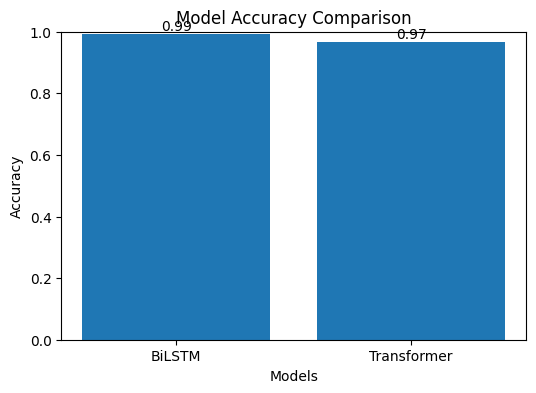

In [87]:
import matplotlib.pyplot as plt

models = ["BiLSTM", "Transformer"]
accuracy = [bilstm_acc, transformer_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.ylim(0,1)
plt.show()

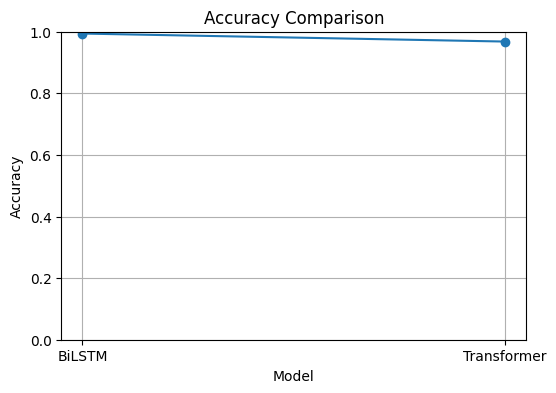

In [88]:
plt.figure(figsize=(6,4))

plt.plot(models, accuracy, marker='o')

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0,1)
plt.grid(True)

plt.show()

In [89]:
import numpy as np

y_pred_bilstm = model.predict(X_test)
y_pred_bilstm = np.argmax(y_pred_bilstm, axis=1)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [90]:
y_pred_transformer = model_transformer.predict(X_test)
y_pred_transformer = np.argmax(y_pred_transformer, axis=1)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [91]:
from sklearn.metrics import confusion_matrix

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)
cm_transformer = confusion_matrix(y_test, y_pred_transformer)

print("BiLSTM Confusion Matrix:\n", cm_bilstm)
print("Transformer Confusion Matrix:\n", cm_transformer)

BiLSTM Confusion Matrix:
 [[ 534    0    3    0]
 [   0  678    0    0]
 [   6    0 1597    3]
 [  11    2    2 1704]]
Transformer Confusion Matrix:
 [[ 534    0    0    3]
 [   0  678    0    0]
 [  48    7 1483   68]
 [  17    2    0 1700]]


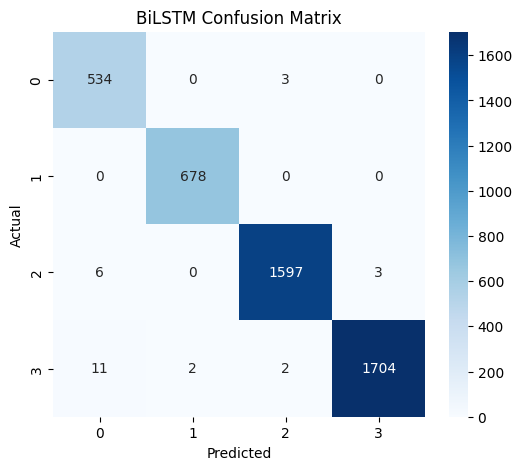

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm_bilstm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

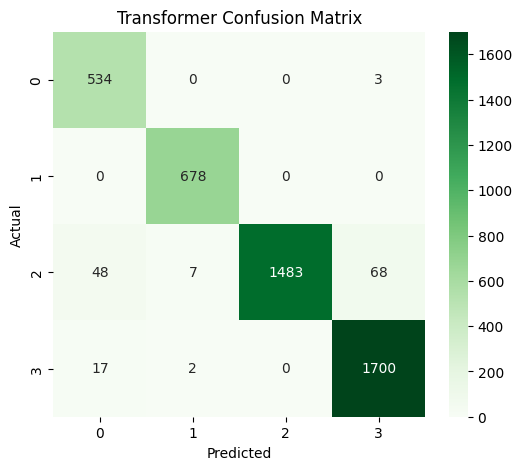

In [93]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_transformer,
            annot=True,
            fmt='d',
            cmap="Greens")

plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [94]:
history_transformer = model_transformer.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9887 - loss: 0.0351 - val_accuracy: 0.9868 - val_loss: 0.0426
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9910 - loss: 0.0286 - val_accuracy: 0.9892 - val_loss: 0.0309
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9896 - loss: 0.0314 - val_accuracy: 0.9938 - val_loss: 0.0191
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9910 - loss: 0.0266 - val_accuracy: 0.9945 - val_loss: 0.0177
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.9890 - val_loss: 0.0307
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9914 - val_loss: 0.0205
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9938 - val_loss: 0.0186
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.

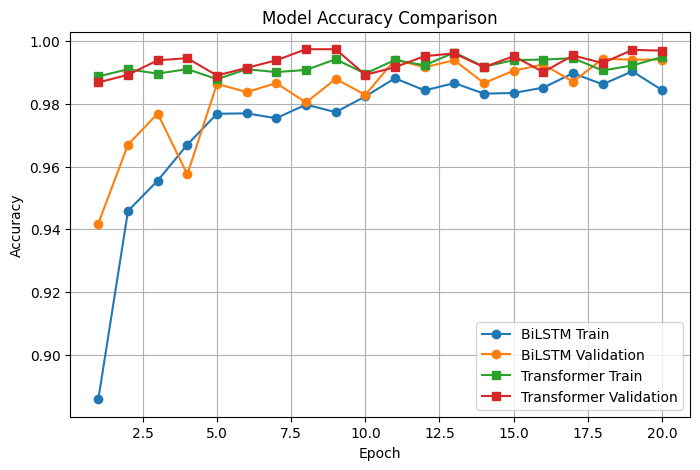

In [95]:
import matplotlib.pyplot as plt

# training history থেকে accuracy নিন
bilstm_train = history.history['accuracy']
bilstm_val = history.history['val_accuracy']

transformer_train = history_transformer.history['accuracy']
transformer_val = history_transformer.history['val_accuracy']

epochs = range(1, len(bilstm_train)+1)

plt.figure(figsize=(8,5))

plt.plot(epochs, bilstm_train, label="BiLSTM Train", marker='o')
plt.plot(epochs, bilstm_val, label="BiLSTM Validation", marker='o')

plt.plot(epochs, transformer_train, label="Transformer Train", marker='s')
plt.plot(epochs, transformer_val, label="Transformer Validation", marker='s')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [96]:
model.save("bilstm_exercise_model.h5")
model_transformer.save("transformer_exercise_model.h5")

In [97]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)